# Разработка решения для компании «Не бит, не крашен» для привлечения новых клиентов и расчета рыночной стоимости автомобиля

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. Компания предоставила исторические данные:
- технические характеристики,
- комплектации и цены автомобилей.

**Формирование задачи**

Необходимо построить модель для определения стоимости. 

Заказчику важны:
    
- качество предсказания (RMSE < 2500);
- скорость предсказания;
- время обучения.

**Описание данных**

Данные для работы находятся в датасете `autos.csv`

Для этой задачи заказчик предоставил данные с признаками:

| Признак               | Описание                                         |
|-----------------------|--------------------------------------------------|
| **DateCrawled**       | дата скачивания анкеты из базы                   |
| **VehicleType**       | тип автомобильного кузова                        |
| **RegistrationYear**  | год регистрации автомобиля                       |
| **Gearbox**           | тип коробки передач                              |
| **Power**             | мощность (л. с.)                                 |
| **Model**             | модель автомобиля                                |
| **Kilometer**         | пробег (км)                                      |
| **RegistrationMonth** | месяц регистрации автомобиля                     |
| **FuelType**          | тип топлива                                      |
| **Brand**             | марка автомобиля                                 |
| **Repaired**       | была машина в ремонте или нет                    |
| **DateCreated**       | дата создания анкеты                             |
| **NumberOfPictures**  | количество фотографий автомобиля                 |
| **PostalCode**        | почтовый индекс владельца анкеты (пользователя)  |
| **LastSeen**          | дата последней активности пользователя           |
| **Price**             | цена (евро) - целевой признак                    |


**План исследования**

1. Загрузка и предообработка данных
2. Исследовательский анализ данных
3. Корреляционный анализ
4. Подготовка данных
5. Обучение моделей и анализ качества и скорости работы на тренировочной выборке
6. Проверка модели на тестовой выборке

## Загрузка и предобработка данных

In [61]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
!pip install phik -q
import phik 
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
!pip install lightgbm -q
!pip install sweetviz -q
import sweetviz as sv
import lightgbm as lgb
from sklearn.inspection import permutation_importance
RANDOM_STATE = 42

In [2]:
#считаем csv - файл с данными `autos.csv`
try:
    autos = pd.read_csv('autos.csv')
except:
    autos = pd.read_csv('https://code.s3.yandex.net/datasets/autos.csv')

In [3]:
display(autos.head())

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


<div style="border:solid green 2px; padding: 20px">
Вывод: на первом этапе был открыт файл с данными, были выведены первые строки датафрейма. Уже можно отметить, что явно имеются пропуски. Также в описании проекта был заявлен столбец `NotRepaired`, но в датасете есть только `Repaired`. Описание проекта изменено.

## Предобработка данных

### Общий анализ данных

Приведем название столбцов к нижнему регистру.

In [4]:
autos.columns = autos.columns.str.lower()
autos = autos.rename(columns={'datecrawled': 'date_crawled',
                              'vehicletype': 'vehicle_type',
                              'registrationyear':'registration_year',
                              'registrationmonth':'registration_month',
                              'fueltype':'fuel_type',
                              'datecreated':'date_created',
                              'numberofpictures':'number_of_pictures',
                              'postalcode':'postal_code',
                              'lastseen':'last_seen'})

In [5]:
def desc_data(data): #создадим функцию для описания датасета
    display(data.head(10)) 
    list_c = data.columns
    print(data.info())
    print('-'* 25)
    print('Количество полных дубликатов ', data.duplicated().sum())
    for col_l in list_c:
        print('-'* 25)
        print(col_l,': кол-во NaN',data[col_l].isna().sum(),\
              ', процент NaN', round(data[col_l].isna().mean()*100,2),'%')
        print(data[col_l].describe())

In [6]:
desc_data(autos)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
5,2016-04-04 17:36:23,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,2016-04-04 00:00:00,0,33775,2016-04-06 19:17:07
6,2016-04-01 20:48:51,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,2016-04-01 00:00:00,0,67112,2016-04-05 18:18:39
7,2016-03-21 18:54:38,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
8,2016-04-04 23:42:13,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,2016-04-04 00:00:00,0,94505,2016-04-04 23:42:13
9,2016-03-17 10:53:50,999,small,1998,manual,101,golf,150000,0,NaN,volkswagen,NaN,2016-03-17 00:00:00,0,27472,2016-03-31 17:17:06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   date_crawled        354369 non-null  object
 1   price               354369 non-null  int64 
 2   vehicle_type        316879 non-null  object
 3   registration_year   354369 non-null  int64 
 4   gearbox             334536 non-null  object
 5   power               354369 non-null  int64 
 6   model               334664 non-null  object
 7   kilometer           354369 non-null  int64 
 8   registration_month  354369 non-null  int64 
 9   fuel_type           321474 non-null  object
 10  brand               354369 non-null  object
 11  repaired            283215 non-null  object
 12  date_created        354369 non-null  object
 13  number_of_pictures  354369 non-null  int64 
 14  postal_code         354369 non-null  int64 
 15  last_seen           354369 non-null  object
dtypes:

### Удаление дубликатов

Наблюдаются 4 полных дубликата.

In [7]:
autos.loc[autos.duplicated(), :]

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
171088,2016-03-08 18:42:48,1799,coupe,1999,auto,193,clk,20000,7,petrol,mercedes_benz,no,2016-03-08 00:00:00,0,89518,2016-03-09 09:46:57
231258,2016-03-28 00:56:10,1000,small,2002,manual,83,other,150000,1,petrol,suzuki,no,2016-03-28 00:00:00,0,66589,2016-03-28 08:46:21
258109,2016-04-03 09:01:15,4699,coupe,2003,auto,218,clk,125000,6,petrol,mercedes_benz,yes,2016-04-03 00:00:00,0,75196,2016-04-07 09:44:54
325651,2016-03-18 18:46:15,1999,wagon,2001,manual,131,passat,150000,7,gasoline,volkswagen,no,2016-03-18 00:00:00,0,36391,2016-03-18 18:46:15


Удалим дубликаты.

In [8]:
autos = autos.drop_duplicates()
print('Количество полных дубликатов:', autos.duplicated().sum())

Количество полных дубликатов: 0


### Изменение формата данных

| Признак                | Описание                                        | Формат | Примечание                                   |
|------------------------|-------------------------------------------------|--------|----------------------------------------------|
| **date_crawled**       | дата скачивания анкеты из базы                  | object | Необходимо изменить формат на формат даты    |
| **vehicle_type**       | тип автомобильного кузова                       | object | Формат оптимален                             |
| **registration_year**  | год регистрации автомобиля                      | int64  | Формат оптимален                             |
| **gearbox**            | тип коробки передач                             | object | Формат оптимален                             |
| **power**              | мощность (л. с.)                                | int64  | Формат оптимален                             |
| **model**              | модель автомобиля                               | object | Формат оптимален                             |
| **kilometer**          | пробег (км)                                     | int64  | Формат оптимален                             |
| **registration_month** | месяц регистрации автомобиля                    | int64  | Формат оптимален                             |
| **fuel_type**          | тип топлива                                     | object | Формат оптимален                             |
| **brand**              | марка автомобиля                                | object | Формат оптимален                             |
| **repaired**           | была машина в ремонте или нет                   | object | Формат оптимален                             |
| **date_created**       | дата создания анкеты                            | object | Необходимо изменить формат на формат даты    |
| **number_of_pictures** | количество фотографий автомобиля                | int64  | Формат оптимален                             |
| **postal_code**        | почтовый индекс владельца анкеты (пользователя) | int64  | Формат оптимален  |
| **last_seen**          | дата последней активности пользователя          | object | Необходимо изменить формат на формат даты    |
| **price**              | цена (евро) - целевой признак                   | int64  | Формат оптимален                             |

In [9]:
autos['date_crawled'] = pd.to_datetime(autos['date_crawled']).dt.normalize()
autos['date_created'] = pd.to_datetime(autos['date_created']).dt.normalize()
autos['last_seen'] = pd.to_datetime(autos['last_seen']).dt.normalize()
autos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 354365 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354365 non-null  datetime64[ns]
 1   price               354365 non-null  int64         
 2   vehicle_type        316875 non-null  object        
 3   registration_year   354365 non-null  int64         
 4   gearbox             334532 non-null  object        
 5   power               354365 non-null  int64         
 6   model               334660 non-null  object        
 7   kilometer           354365 non-null  int64         
 8   registration_month  354365 non-null  int64         
 9   fuel_type           321470 non-null  object        
 10  brand               354365 non-null  object        
 11  repaired            283211 non-null  object        
 12  date_created        354365 non-null  datetime64[ns]
 13  number_of_pictures  354365 no

### Проверка уникальных значений и замена пропусков

Проверим уникальные значения для категориальных признаков.

In [10]:
def unique_znach(data): #функция для вывода уникальных значений
    list_c = data.select_dtypes(include='object').columns.tolist()
    for i in list_c:
        print('Уникальные значения для столбца "',i,'" :')
        print(data[i].unique())
        print('-'* 25)

In [11]:
unique_znach(autos)

Уникальные значения для столбца " vehicle_type " :
[nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']
-------------------------
Уникальные значения для столбца " gearbox " :
['manual' 'auto' nan]
-------------------------
Уникальные значения для столбца " model " :
['golf' nan 'grand' 'fabia' '3er' '2_reihe' 'other' 'c_max' '3_reihe'
 'passat' 'navara' 'ka' 'polo' 'twingo' 'a_klasse' 'scirocco' '5er'
 'meriva' 'arosa' 'c4' 'civic' 'transporter' 'punto' 'e_klasse' 'clio'
 'kadett' 'kangoo' 'corsa' 'one' 'fortwo' '1er' 'b_klasse' 'signum'
 'astra' 'a8' 'jetta' 'fiesta' 'c_klasse' 'micra' 'vito' 'sprinter' '156'
 'escort' 'forester' 'xc_reihe' 'scenic' 'a4' 'a1' 'insignia' 'combo'
 'focus' 'tt' 'a6' 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe'
 'sportage' 'sorento' 'v40' 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3'
 'almera' 'megane' 'lupo' 'r19' 'zafira' 'caddy' 'mondeo' 'cordoba' 'colt'
 'impreza' 'vectra' 'berlingo' 'tiguan' 'i_reihe' 'espace' 'sharan'
 '6

Заменим пропуски на значение 'other' в двух столбцах ('model' и 'vehicle_type'), остальные заменим на моду.

In [12]:
autos['model']=autos['model'].fillna('other')
autos['vehicle_type']=autos['vehicle_type'].fillna('other')
autos['gearbox']=autos['gearbox'].fillna(autos['gearbox'].mode().values[0])
autos['fuel_type']=autos['fuel_type'].fillna(autos['fuel_type'].mode().values[0])
autos['repaired']=autos['repaired'].fillna(autos['repaired'].mode().values[0])

Заменим значение 'gasoline' на 'petrol', т.к. это одно и тоже. Petrol применяется в Великобритании и других странах Содружества, а gasoline — в США и Канаде.

In [13]:
autos['fuel_type'] = autos['fuel_type'].replace('gasoline', 'petrol')

In [14]:
autos['fuel_type'].unique()

array(['petrol', 'lpg', 'other', 'hybrid', 'cng', 'electric'],
      dtype=object)

In [15]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 354365 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        354365 non-null  datetime64[ns]
 1   price               354365 non-null  int64         
 2   vehicle_type        354365 non-null  object        
 3   registration_year   354365 non-null  int64         
 4   gearbox             354365 non-null  object        
 5   power               354365 non-null  int64         
 6   model               354365 non-null  object        
 7   kilometer           354365 non-null  int64         
 8   registration_month  354365 non-null  int64         
 9   fuel_type           354365 non-null  object        
 10  brand               354365 non-null  object        
 11  repaired            354365 non-null  object        
 12  date_created        354365 non-null  datetime64[ns]
 13  number_of_pictures  354365 no

### Удаление невлияющих признаков

В составе датасета присутствуют столбцы, информация в которых не влияет на стоимость автомобиля. Это столбцы:
- registration_month,
- date_created,
- number_of_pictures,
- postal_code,
- last_seen.

В отношении столбца 'postal_code' необходимо отметить, что, судя по валюте цены, все автомобили находятся в еврозоне (Германия) и показатель местоположения объекта не влияет на цену так сильно, как в РФ. Поэтому данный признак не учитывается.

Проверим уникальные значения года в столбце 'date_crawled'.

In [16]:
autos['year'] = pd.DatetimeIndex(autos['date_crawled']).year
autos['month'] = pd.DatetimeIndex(autos['date_crawled']).month

In [17]:
print('Год продаж автомобилей:',autos['year'].unique())
print('Месяц продаж автомобилей:',autos['month'].unique())

Год продаж автомобилей: [2016]
Месяц продаж автомобилей: [3 4]


С учетом инфляции в еврозоне предполагается, что дата не может серьезным образом влиять на стоимость автомобиля. Но модель не будет подходить для автомобилей, которые будут продаваться гораздо позже. Это необходимо учитывать, используя индекс инфляции. Принято решение удалить столбец 'date_crawled'.

In [18]:
autos = autos.drop(columns=['registration_month','date_created','number_of_pictures','postal_code',\
                            'last_seen','date_crawled','year','month'])
autos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 354365 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              354365 non-null  int64 
 1   vehicle_type       354365 non-null  object
 2   registration_year  354365 non-null  int64 
 3   gearbox            354365 non-null  object
 4   power              354365 non-null  int64 
 5   model              354365 non-null  object
 6   kilometer          354365 non-null  int64 
 7   fuel_type          354365 non-null  object
 8   brand              354365 non-null  object
 9   repaired           354365 non-null  object
dtypes: int64(4), object(6)
memory usage: 29.7+ MB


<div style="border:solid green 2px; padding: 20px">
Вывод: на втором этапе была проведена предобработка данных. Названия столбцов приведены к нижнему регистру. Удалены дубликаты. Наблюдаются пропуски в категориальных признаках. Пропуски заменены. Стоит порекомендовать заказчику включить в анкету признаки, обязательные к заполнению, т.к. их отсутствие влияет на результат. Либо пропуски могут быть результатом некорректной выгрузки данных.

## Исследовательский анализ данных

In [19]:
autos.describe()

,price,registration_year,power,kilometer
count,354365.000000,354365.000000,354365.000000,354365.000000
mean,4416.679830,2004.234481,110.093816,128211.363989
std,4514.176349,90.228466,189.851330,37905.083858
min,0.000000,1000.000000,0.000000,5000.000000
25%,1050.000000,1999.000000,69.000000,125000.000000
50%,2700.000000,2003.000000,105.000000,150000.000000
75%,6400.000000,2008.000000,143.000000,150000.000000
max,20000.000000,9999.000000,20000.000000,150000.000000


Имеются данные о нулевой стоимости и мощности. Это явные выбросы.

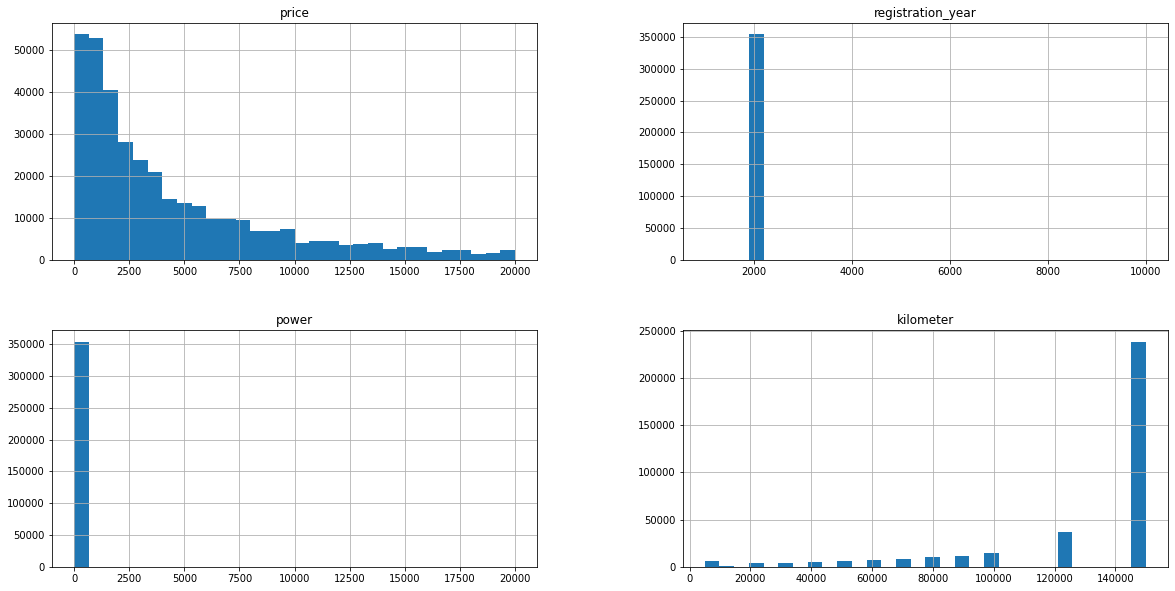

In [20]:
autos.hist(figsize=(20, 10),bins=30);

Гистограммы также показывают, что имеются явные выбросы. Удалим данные о годе регистрации после 2015 года. Если дата скачивания анкеты с данными о продаже ограничивается март-апрелем 2016 года, то год регистрации автомобиля не может быть после этой даты. 2016 год также маловероятен, учитывая время подготовки автомобиля к продаже и времени на сделку. Также первым годом регистрации автомобилей в Европе стал 1892 год (Берлин).

In [21]:
autos_new = autos.query('registration_year < 2016 & registration_year>1891')

Вызывает вопросы и мощность автомобилей выше 4500 л.с. (мощность Belaz 75710).

In [22]:
autos_nul = autos_new.query('power==0')
display(autos_nul)

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,fuel_type,brand,repaired
0,480,other,1993,manual,0,golf,150000,petrol,volkswagen,no
15,450,small,1910,manual,0,ka,5000,petrol,ford,no
32,245,sedan,1994,manual,0,golf,150000,petrol,volkswagen,no
40,0,other,1990,manual,0,corsa,150000,petrol,opel,no
54,4700,wagon,2005,manual,0,signum,150000,petrol,opel,no
...,...,...,...,...,...,...,...,...,...,...
354338,180,other,1995,manual,0,other,125000,petrol,opel,no
354346,2600,other,2005,auto,0,c_klasse,150000,petrol,mercedes_benz,no
354363,1150,bus,2000,manual,0,zafira,150000,petrol,opel,no
354364,0,other,2005,manual,0,colt,150000,petrol,mitsubishi,yes


In [23]:
autos_new = autos_new.query('power<4500')

Цена врядли может составлять 0 евро. Поэтому данные об этих автомобилях удаляем. На сайтах можно найти автомобили от 10 евро. Вероятно, по мнению немецких покупателей/продавцов это автомобили на металлолом.

In [24]:
autos_new = autos_new.query('price>10')

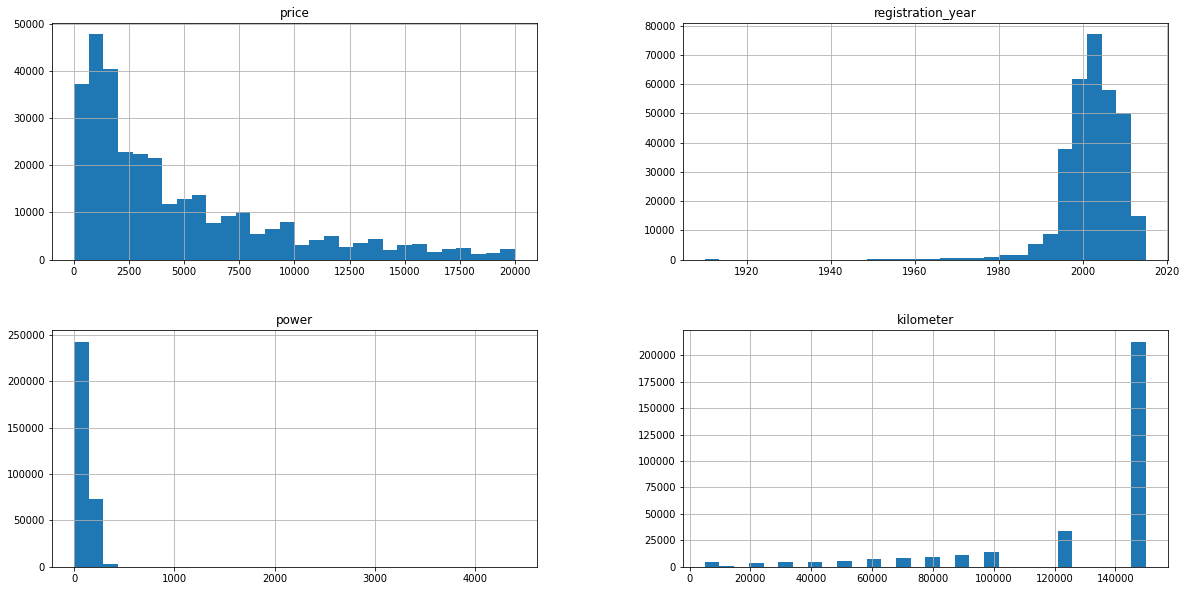

In [25]:
autos_new.hist(figsize=(20, 10),bins=30);

In [26]:
autos_new.describe()

,price,registration_year,power,kilometer
count,319521.000000,319521.000000,319521.000000,319521.000000
mean,4690.679683,2002.237239,110.703966,128102.127873
std,4562.862657,6.609387,73.618613,37431.604351
min,11.000000,1910.000000,0.000000,5000.000000
25%,1250.000000,1999.000000,73.000000,125000.000000
50%,2999.000000,2003.000000,105.000000,150000.000000
75%,6800.000000,2007.000000,143.000000,150000.000000
max,20000.000000,2015.000000,4400.000000,150000.000000


In [27]:
def hist_plot(data,index,bins):
    plt.figure(figsize=(20, 5))
    plt.suptitle('Гистограмма и диаграмма размаха для показателя "' + index+'"', fontsize=20, y=1.05)
        
    
    plt.subplot(1, 2, 1)
    mean = np.mean(data[index])
    median = np.median(data[index])
    sns.histplot(data[index], bins=bins, kde=True, color='skyblue')
    plt.axvline(mean, color='r', linestyle='dashed', linewidth=1, label=f'Среднее: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='dashed', linewidth=1, label=f'Медиана: {median:.2f}');
    plt.ylabel('Количество показателей')
    plt.title('Гистограмма по значению ' + index, fontsize=16)
    plt.legend()
    plt.xlabel(index);
    
    plt.subplot(1, 2, 2)
    ax = sns.boxplot(y=index, data=data)
    plt.title('Boxplot для показателя ' + index, fontsize=16)
    plt.axhline(y=mean, color='g', linestyle='--')
    plt.ylabel(index, fontsize=14);
    plt.show()

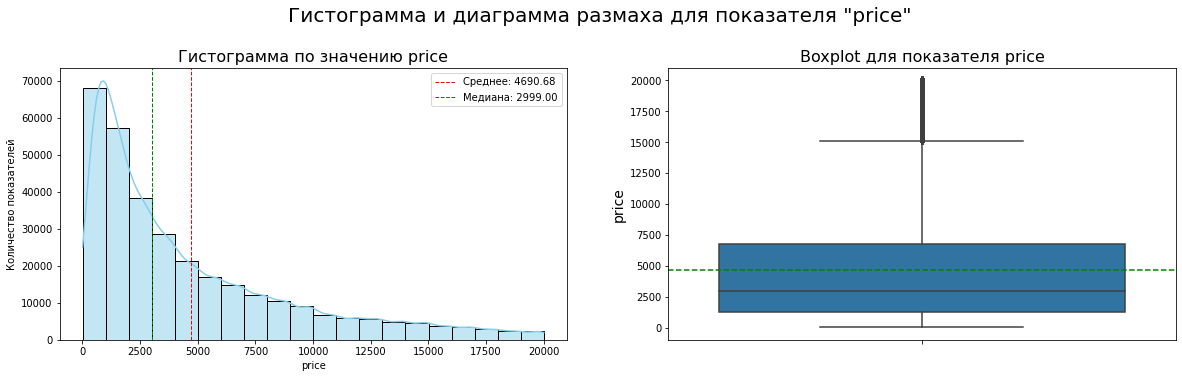

In [28]:
hist_plot(autos_new,'price',20)

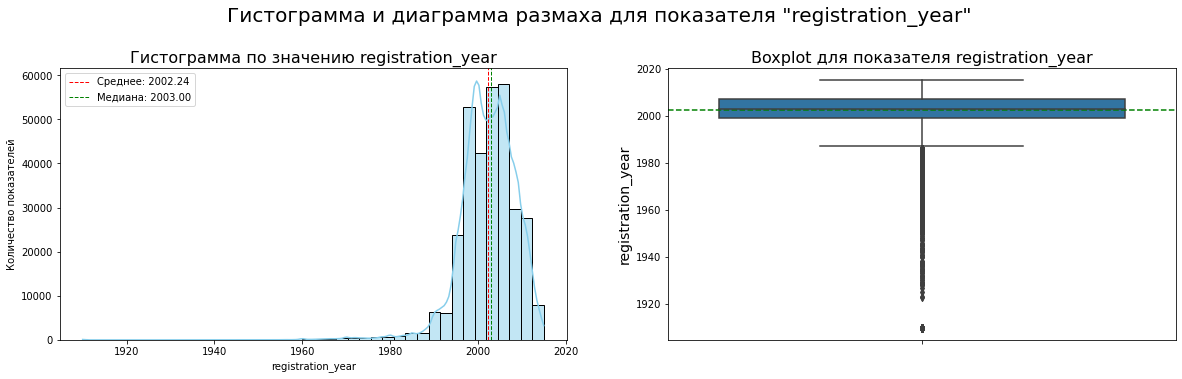

In [29]:
hist_plot(autos_new,'registration_year',40)

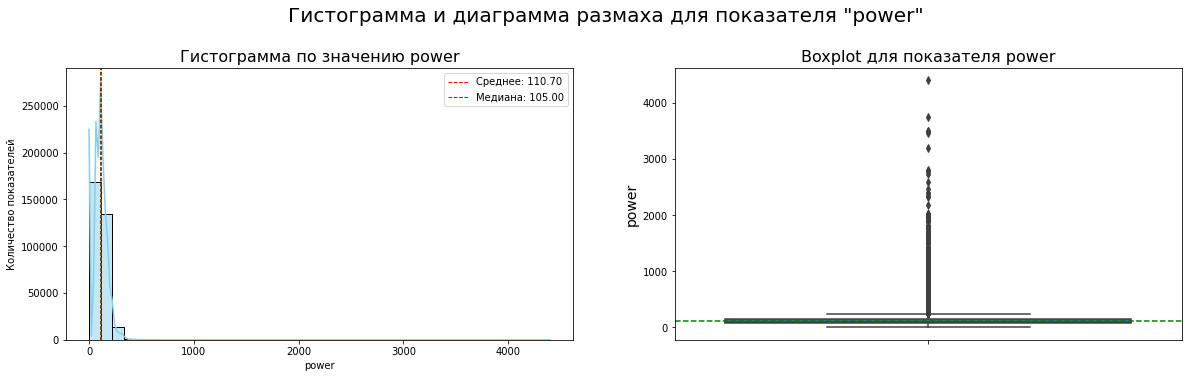

In [30]:
hist_plot(autos_new,'power',40)

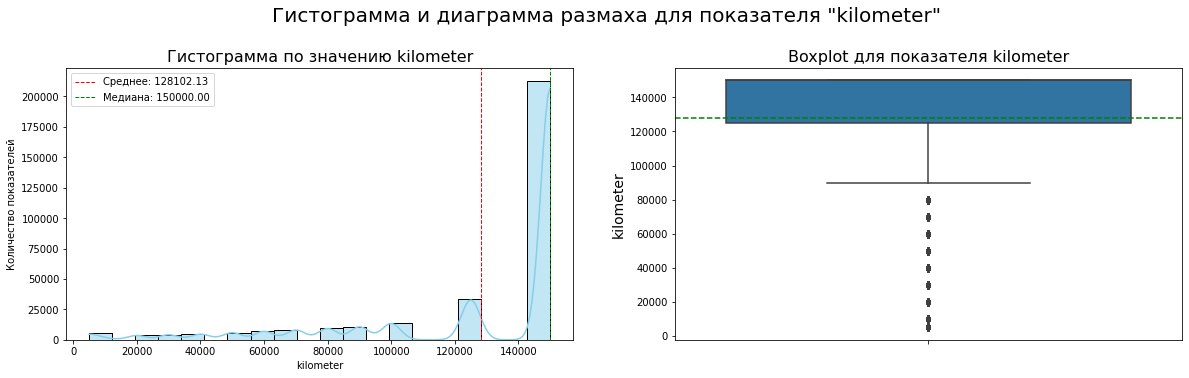

In [31]:
hist_plot(autos_new,'kilometer',20)

In [32]:
autos_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 319521 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              319521 non-null  int64 
 1   vehicle_type       319521 non-null  object
 2   registration_year  319521 non-null  int64 
 3   gearbox            319521 non-null  object
 4   power              319521 non-null  int64 
 5   model              319521 non-null  object
 6   kilometer          319521 non-null  int64 
 7   fuel_type          319521 non-null  object
 8   brand              319521 non-null  object
 9   repaired           319521 non-null  object
dtypes: int64(4), object(6)
memory usage: 26.8+ MB


Рассчитаем процент удаления.

In [33]:
print('Процент удаления составил:',format(1-autos_new.shape[0]/autos.shape[0], ".0%"))

Процент удаления составил: 10%


В составе автомобилей присутствуют и ретроавтомобили. Используем классификацию:
    
- "Ветеран" (группа А) – машины, выпущенные до 1918 года.
- "Винтаж" (группа В) – автомобили 1919-1930 года выпуска.
- "Поствинтаж" (группа С) – годы выпуска с 1931 по 1945.
- "Послевоенные" (группа D) – с 1946 года по 1960 год.
- "Шестидесятники" (группа Е) – годы выпуска с 1961 по 1970.
- "Семидесятники" (группа F) – с 1970 года по 1 января 1987 года.

Остальные автомобили будут отмечены как современные (группа G). Фактор состояния возьмет на себя признак "registration_year".

In [34]:
def retro_category(year): #создаем функцию для категоризации данных в столбце `registration_year`
        if year <=1918:
            return 'A'
        elif 1919 <= year<=1930:
            return 'B'
        elif 1931<= year<=1945:
            return 'C'
        elif 1946<=year<=1960:
            return 'D'
        elif 1961<=year<=1970:
            return 'E'
        elif 1970<year<=1987:
            return 'F'
        else:
            return 'G'
        
        
autos_new['retro_category'] = autos_new['registration_year'].apply(retro_category)
autos_new['retro_category'].value_counts() #подсчитываем значения по категориям

G    312886
F      5269
E       970
D       289
C        48
A        45
B        14
Name: retro_category, dtype: int64

<div style="border:solid green 2px; padding: 20px">
Вывод: на третьем этапе был проведен исследовательский анализ данных. Данные сами по себе вызывают большие вопросы. Если бы была возможность связаться с заказчиком работ, вопрос с нестыковками можно было бы закрыть. Возможна некорректная выгрузка. Процент удаления достаточно большой. Но замена данных модой приведет к заведомо ложному результату. Наблюдается также наличие большого количества раритетных машин, суды по году регистрации. У этих машин совершенно другие условия рынка. Поэтому был введен дополнительный столбец 'retro_category'.

## Корреляционный анализ

Ниже представлена таблица коэффициентов корреляции (шкала Чеддока):

| Значение       | Интерпретация  |
|:--------------:|:--------------:|
| от 0 до 0,3    | очень слабая   |
| от 0,3 до 0,5  | слабая         |
| от 0, 5 до 0,7 | средняя        |
| от 0,7 до 0,9 | высокая        |
| от 0,9 до 1    | очень высокая  |

Используем библиотеку phik для подсчёта корреляции между признаками разных типов данных.

In [35]:
# создаём список с наименованиями количественных признаков
interval_cols = autos_new.select_dtypes(include=['int64','float64']).columns.tolist()
    
def corr(data,title):
    # считаем корреляции
    phik_overview = phik_matrix(data, interval_cols=interval_cols)
    
    plot_correlation_matrix(
        phik_overview.values,
        x_labels=phik_overview.columns,
        y_labels=phik_overview.index,
        vmin=0, vmax=1, color_map='Greens',
        title=title,
        fontsize_factor=1.5,
        figsize=(20, 15)
    ) 

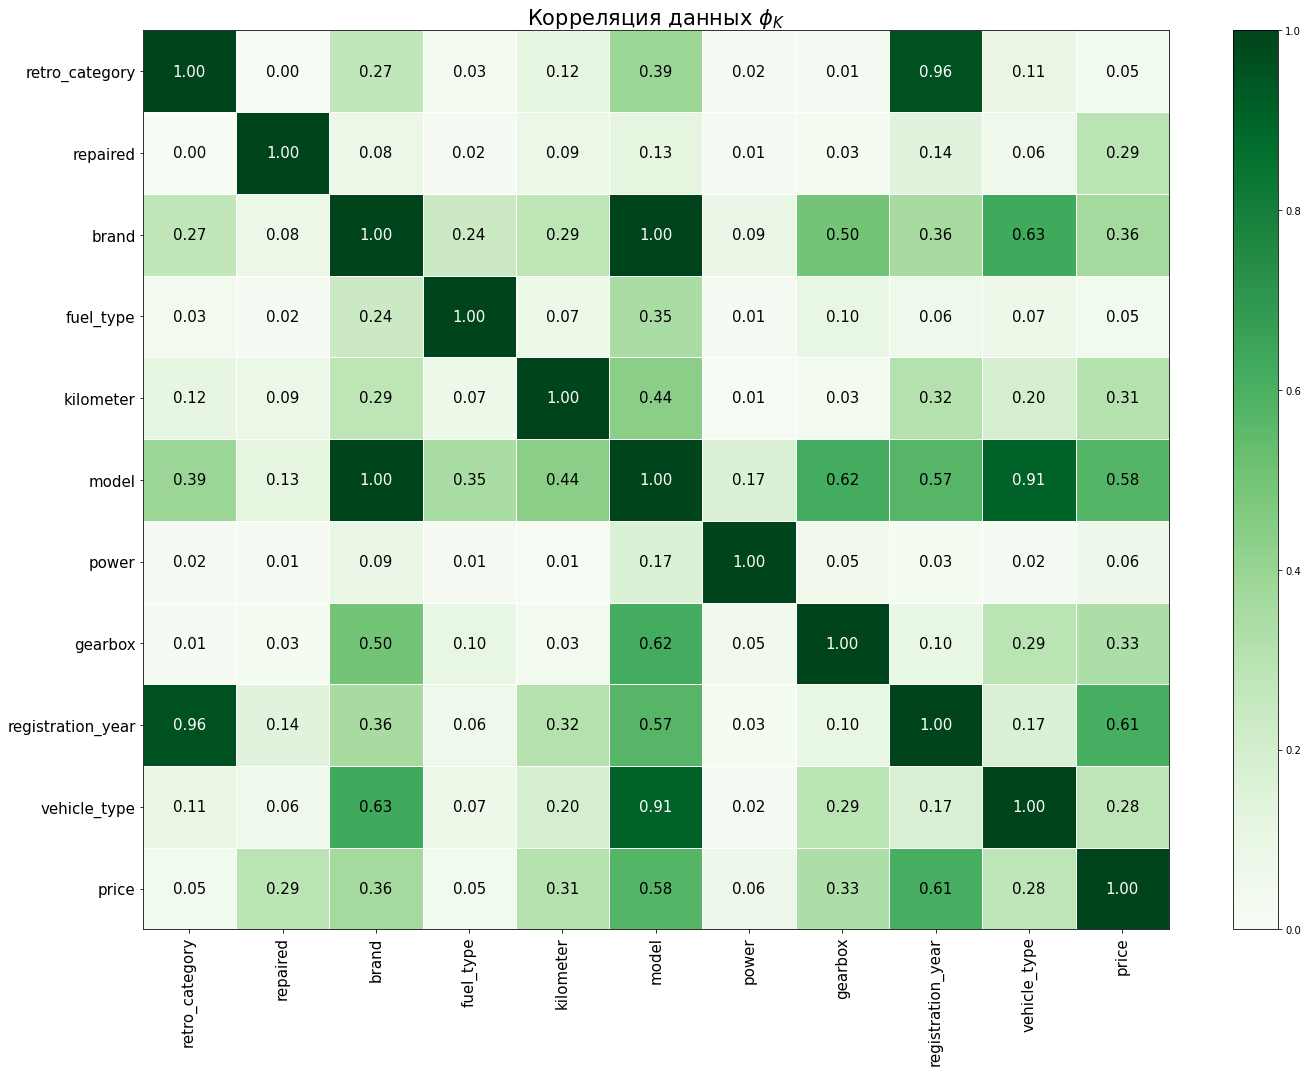

In [36]:
corr(autos_new,r'Корреляция данных $\phi_K$')

<div style="border:solid green 2px; padding: 20px">
Вывод: на четвертом этапе был проведен корреляционный анализ данных. Наблюдается средняя корреляция между целевым признаком и годом регистрации и моделью. Мультиколлинеарности не наблюдается.

## Подготовка данных

За счет удаления ряда стоблцов в датасете 'autos_new' могут присутствовать дубликаты. Проверим это.

In [37]:
autos_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 319521 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              319521 non-null  int64 
 1   vehicle_type       319521 non-null  object
 2   registration_year  319521 non-null  int64 
 3   gearbox            319521 non-null  object
 4   power              319521 non-null  int64 
 5   model              319521 non-null  object
 6   kilometer          319521 non-null  int64 
 7   fuel_type          319521 non-null  object
 8   brand              319521 non-null  object
 9   repaired           319521 non-null  object
 10  retro_category     319521 non-null  object
dtypes: int64(4), object(7)
memory usage: 29.3+ MB


In [38]:
print('Количество полных дубликатов ', autos_new.drop('price',axis=1).duplicated().sum())

Количество полных дубликатов  195334


Удалим данные дубликаты, т.к. они будут искажать модель.

In [39]:
autos_new = autos_new.drop_duplicates(subset=['vehicle_type',
                                              'registration_year',
                                              'gearbox','power',
                                              'model',
                                              'kilometer',
                                              'fuel_type',
                                              'brand',
                                              'repaired',
                                              'retro_category'])
autos_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 124187 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              124187 non-null  int64 
 1   vehicle_type       124187 non-null  object
 2   registration_year  124187 non-null  int64 
 3   gearbox            124187 non-null  object
 4   power              124187 non-null  int64 
 5   model              124187 non-null  object
 6   kilometer          124187 non-null  int64 
 7   fuel_type          124187 non-null  object
 8   brand              124187 non-null  object
 9   repaired           124187 non-null  object
 10  retro_category     124187 non-null  object
dtypes: int64(4), object(7)
memory usage: 11.4+ MB


In [40]:
print('Количество полных дубликатов:',autos_new.drop('price',axis=1).duplicated().sum())

Количество полных дубликатов: 0


In [41]:
# создаём списки с названиями признаков
ohe_columns = ['vehicle_type','gearbox','model','fuel_type','brand','repaired','retro_category']
num_columns = autos_new.drop('price',axis=1).select_dtypes(include=['int64','float64']).columns.tolist()

In [42]:
# разбивка данных
X = autos_new.drop('price',axis=1)
y = autos_new['price']

# разбивка данных на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=RANDOM_STATE)

In [43]:
print('Размер тестовой выборки:',X_test.shape)
print('Размер тренировочной выборки:',X_train.shape)

Размер тестовой выборки: (31047, 10)
Размер тренировочной выборки: (93140, 10)


In [44]:
cat_col_names = ohe_columns
num_col_names = num_columns

## подготовка признаков (масштабирование и кодирование для линейной модели)

encoder = OneHotEncoder(drop='first', sparse_output=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names_out()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train_sc_ohe = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test_sc_ohe = pd.concat([X_test_ohe, X_test_scaled], axis=1)

In [45]:
## подготовка признаков (масштабирование и кодирование для прочих моделей)

# создаём экземпляр класса OrdinalEncoder для кодирования
ordinal_encoder = OrdinalEncoder()

cols_ordinal = ohe_columns

# обучаем OrdinalEncoder на выбранных признаках из тренировочной выборки
# преобразовываем тренировочную выборку
X_train_ord = ordinal_encoder.fit_transform(X_train[cols_ordinal])

# преобразовываем тестовую выборку
X_test_ord = ordinal_encoder.transform(X_test[cols_ordinal])

X_train_ord = pd.DataFrame(X_train_ord, columns=cols_ordinal)
X_test_ord = pd.DataFrame(X_test_ord, columns=cols_ordinal)

X_train_sc_ord = pd.concat([X_train_ord, X_train_scaled], axis=1)
X_test_sc_ord = pd.concat([X_test_ord, X_test_scaled], axis=1)

<div style="border:solid green 2px; padding: 20px">
Вывод: на пятом этапе была проведена подготовка данных. Для категориальных данных использован OneHotEncoder для линейной модели, OrdinalEncoder - для прочих моделей. 

## Обучение моделей и анализ скорости работы на тренировочной выборке

### LinearRegression

In [46]:
# инициализирование модели линейной регрессии
model = LinearRegression()

# подбираем параметры
param_grid = {'fit_intercept': [True,False]}

gs = GridSearchCV(model,
                           param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='neg_root_mean_squared_error')
gs.fit(X_train_sc_ohe, y_train)

res = pd.DataFrame(gs.cv_results_)
display(res)

# выводим лучшие гиперпараметры
print('Гиперпараметры:', gs.best_params_)

# выводим лучшую метрику качества
print('Лучшая метрика RMSE для LinearRegression:', round(gs.best_score_*-1,2))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_fit_intercept,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,6.757763,0.140247,0.016941,0.003241,True,{'fit_intercept': True},-2940.524382,-2930.516723,-2948.293596,-2947.901045,-2907.724549,-2934.992059,15.084596,1
1,8.653972,0.729367,0.064803,0.041175,False,{'fit_intercept': False},-3033.047086,-2974.253752,-2983.377961,-3036.889239,-2971.247887,-2999.763185,29.046483,2


Гиперпараметры: {'fit_intercept': True}
Лучшая метрика RMSE для LinearRegression: 2934.99


### DecisionTreeRegressor

In [47]:
# инициализирование модели
model = DecisionTreeRegressor()

# подбираем параметры
param_grid = {'max_depth': range(3, 11),
              'random_state':[RANDOM_STATE]}

gs = GridSearchCV(model,
                  param_grid,
                  cv=5,
                  n_jobs=-1,
                  scoring='neg_root_mean_squared_error')
gs.fit(X_train_sc_ord, y_train)

res = pd.DataFrame(gs.cv_results_)
display(res.head(10))

# выводим лучшие гиперпараметры
print('Гиперпараметры:', gs.best_params_)

# выводим лучшую метрику качества
print('Лучшая метрика RMSE для DecisionTreeRegressor:', round(gs.best_score_*-1,2))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.062269,0.022847,0.003891,0.000532,3,42,"{'max_depth': 3, 'random_state': 42}",-3200.967264,-3180.681810,-3151.252788,-3212.067721,-3188.075069,-3186.608931,20.696129,8
1,0.065340,0.000950,0.003750,0.000089,4,42,"{'max_depth': 4, 'random_state': 42}",-2948.640710,-2931.867580,-2922.010188,-2963.198979,-2931.121690,-2939.367829,14.693198,7
2,0.076189,0.002027,0.003957,0.000220,5,42,"{'max_depth': 5, 'random_state': 42}",-2795.408602,-2788.278420,-2772.428185,-2826.248503,-2794.621903,-2795.397123,17.496610,6
3,0.087810,0.002342,0.003861,0.000171,6,42,"{'max_depth': 6, 'random_state': 42}",-2678.695667,-2665.966368,-2658.442709,-2723.320265,-2681.193055,-2681.523613,22.493655,5
4,0.102689,0.003914,0.004153,0.000224,7,42,"{'max_depth': 7, 'random_state': 42}",-2591.753720,-2578.245278,-2573.298940,-2647.196442,-2602.003626,-2598.499601,26.360874,4
5,0.118697,0.006097,0.004207,0.000100,8,42,"{'max_depth': 8, 'random_state': 42}",-2509.311056,-2510.653753,-2511.743954,-2580.722005,-2539.828866,-2530.451927,27.582241,3
6,0.127833,0.002843,0.004470,0.000115,9,42,"{'max_depth': 9, 'random_state': 42}",-2456.631968,-2452.166568,-2448.861721,-2504.554994,-2469.109214,-2466.264893,20.340346,2
7,0.140383,0.002712,0.004628,0.000076,10,42,"{'max_depth': 10, 'random_state': 42}",-2436.886310,-2435.124181,-2428.559816,-2483.816792,-2440.575254,-2444.992471,19.798812,1


Гиперпараметры: {'max_depth': 10, 'random_state': 42}
Лучшая метрика RMSE для DecisionTreeRegressor: 2444.99


### LightGBM

LightGBM — это фреймворк, который предоставляет реализацию деревьев принятия решений с градиентным бустингом. LightGBM известен своей более высокой скоростью обучения, хорошей точностью с параметрами по умолчанию, параллельным и GPU обучением, малым использованием памяти и возможностью обработки больших датасетов, которые не всегда помещаются в ней.

Одним из преимуществ использования lightgbm является то, что он может очень хорошо работать с категориальными признаками. Да, этот алгоритм очень мощный, но нужно быть осторожным при использовании его параметров. lightgbm использует специальный метод целочисленного кодирования (предложенный Фишером) для работы с категориальными признаками
. Эксперименты показывают, что этот метод обеспечивает более высокую производительность, чем часто используемое однократное кодирование. Значение по умолчанию для него — 'auto', что означает: пусть lightgbm сам решает, какие признаки являются категориальными.
Но специлисты рекомендуют устанавливать категориальные признаки вручную.


Для работы с LightGBM категориальные признаки должны быть представлены как тип category в Pandas.

LightGBM автоматически обрабатывает такие признаки, что позволяет избежать использования OneHotEncoder, что экономит память и ускоряет обучение.

Рассмотрим два варианта расчета.

#### Вариант при применении X_train_sc_ord

In [48]:
# инициализирование модели
model = lgb.LGBMRegressor()

# подбираем параметры
param_grid = {'num_leaves': [100,150],
              'n_estimators': [100, 500],
              'random_state':[RANDOM_STATE]}

gs = GridSearchCV(
    model,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)
gs.fit(X_train_sc_ord, y_train)

res = pd.DataFrame(gs.cv_results_)
display(res)

# выводим лучшие гиперпараметры
print('Гиперпараметры:', gs.best_params_)

# выводим лучшую метрику качества
print('Лучшая метрика RMSE для LGBMRegressor:', round(gs.best_score_*-1,2))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_num_leaves,param_random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,38.743304,67.327767,0.235703,0.040064,100,100,42,"{'n_estimators': 100, 'num_leaves': 100, 'rand...",-1953.268899,-1955.167258,-1949.481432,-2003.255054,-1967.070803,-1965.648689,19.701578,4
1,7.141151,0.349636,0.259333,0.040474,100,150,42,"{'n_estimators': 100, 'num_leaves': 150, 'rand...",-1943.932867,-1942.297469,-1927.544042,-1989.204027,-1955.284537,-1951.652588,20.744329,3
2,21.199174,1.122228,1.221727,0.069996,500,100,42,"{'n_estimators': 500, 'num_leaves': 100, 'rand...",-1930.354183,-1927.400881,-1918.752358,-1968.496954,-1942.217250,-1937.444325,17.248635,1
3,28.899304,0.630780,1.720528,0.038709,500,150,42,"{'n_estimators': 500, 'num_leaves': 150, 'rand...",-1942.750714,-1935.832477,-1923.570899,-1985.893201,-1950.905695,-1947.790597,21.054705,2


Гиперпараметры: {'n_estimators': 500, 'num_leaves': 100, 'random_state': 42}
Лучшая метрика RMSE для LGBMRegressor: 1937.44


#### Вариант встроенной кодировки

In [49]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 93140 entries, 43602 to 344629
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   vehicle_type       93140 non-null  object
 1   registration_year  93140 non-null  int64 
 2   gearbox            93140 non-null  object
 3   power              93140 non-null  int64 
 4   model              93140 non-null  object
 5   kilometer          93140 non-null  int64 
 6   fuel_type          93140 non-null  object
 7   brand              93140 non-null  object
 8   repaired           93140 non-null  object
 9   retro_category     93140 non-null  object
dtypes: int64(3), object(7)
memory usage: 7.8+ MB


In [50]:
def cat_type(data):
    for col in data.columns:
        type = data[col].dtype
        if type == 'object':
            data[col] = data[col].astype('category')

In [51]:
cat_type(X_train)

In [52]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 93140 entries, 43602 to 344629
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   vehicle_type       93140 non-null  category
 1   registration_year  93140 non-null  int64   
 2   gearbox            93140 non-null  category
 3   power              93140 non-null  int64   
 4   model              93140 non-null  category
 5   kilometer          93140 non-null  int64   
 6   fuel_type          93140 non-null  category
 7   brand              93140 non-null  category
 8   repaired           93140 non-null  category
 9   retro_category     93140 non-null  category
dtypes: category(7), int64(3)
memory usage: 3.6 MB


In [53]:
cat_type(X_test)

In [54]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 31047 entries, 128992 to 203014
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   vehicle_type       31047 non-null  category
 1   registration_year  31047 non-null  int64   
 2   gearbox            31047 non-null  category
 3   power              31047 non-null  int64   
 4   model              31047 non-null  category
 5   kilometer          31047 non-null  int64   
 6   fuel_type          31047 non-null  category
 7   brand              31047 non-null  category
 8   repaired           31047 non-null  category
 9   retro_category     31047 non-null  category
dtypes: category(7), int64(3)
memory usage: 1.2 MB


In [55]:
gs = GridSearchCV(
    model,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)
gs.fit(X_train, y_train)

res = pd.DataFrame(gs.cv_results_)
display(res)

# выводим лучшие гиперпараметры
print('Гиперпараметры:', gs.best_params_)

# выводим лучшую метрику качества
print('Лучшая метрика RMSE для LGBMRegressor:', round(gs.best_score_*-1,2))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_num_leaves,param_random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,5.434813,0.090160,0.355742,0.041890,100,100,42,"{'n_estimators': 100, 'num_leaves': 100, 'rand...",-1896.190966,-1920.976703,-1912.053812,-1951.314510,-1924.908652,-1921.088929,18.053978,3
1,7.505348,0.179400,0.373777,0.035603,100,150,42,"{'n_estimators': 100, 'num_leaves': 150, 'rand...",-1899.379583,-1914.224889,-1902.917188,-1954.320002,-1918.402783,-1917.848889,19.532809,2
2,110.520375,100.481930,1.660300,0.040979,500,100,42,"{'n_estimators': 500, 'num_leaves': 100, 'rand...",-1893.878568,-1916.971744,-1905.227850,-1942.384510,-1923.712665,-1916.435067,16.498621,1
3,34.154786,4.695349,2.324495,0.036685,500,150,42,"{'n_estimators': 500, 'num_leaves': 150, 'rand...",-1920.796907,-1925.249317,-1910.874874,-1957.441529,-1930.651932,-1929.002912,15.630278,4


Гиперпараметры: {'n_estimators': 500, 'num_leaves': 100, 'random_state': 42}
Лучшая метрика RMSE для LGBMRegressor: 1916.44


<div style="border:solid green 2px; padding: 20px">
Вывод: на шестом этапе было проведено обучение моделей. Полученные метрики (RMSE) составили:
        
- LinearRegression (fit_intercept=True) - 2934.99
- DecisionTreeRegressor (depth=10) - 2444.99
- LGBMRegressor с внутренней кодировкой ('n_estimators': 500, 'num_leaves': 100) - 1916.44
    
Учитывая градацию предпочтений заказчика, препочтение лучше отдать LightGBM. Время выполнения дольше, но метрика получается наилучшая. LinearRegression же не достигает по метрике условий задачи (RMSE < 2500).

## Проверка модели на тестовой выборке

**CPU times** — время, затраченное процессором компьютера на обработку задачи (программы).
**Wall time** — это общее время, которое требуется для начала и завершения процесса или операции, измеренное обычными часами.

In [56]:
%%time
model = lgb.LGBMRegressor(random_state=RANDOM_STATE,n_estimators=500, num_leaves=100)
model.fit(X_train, y_train)

CPU times: user 24.6 s, sys: 325 ms, total: 24.9 s
Wall time: 25.6 s


LGBMRegressor(n_estimators=500, num_leaves=100, random_state=42)

In [57]:
%%time
predictions = model.predict(X_test)

CPU times: user 2.94 s, sys: 26.3 ms, total: 2.96 s
Wall time: 3 s


In [62]:
rmse = math.sqrt(mean_squared_error(predictions, y_test))
print('RMSE для модели LightGBM:',round(rmse,2))

RMSE для модели LightGBM: 1907.87


Проанализируем важность признаков.

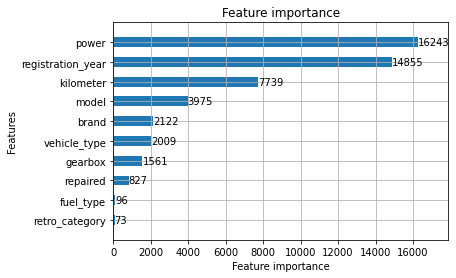

In [63]:
# посмотрим на то, какие признаки влияют больше всего
lgb.plot_importance(model, height=.5);

<div style="border:solid green 2px; padding: 20px">
Вывод: на седьмом этапе была произведена проверка работы модели на тестовой выборке. RMSE соответствует условиям проекта (менее 2500). Наиболее важными признаками являются:
    
- power
- registration_year
- kilometer
- model
- brand

## Общий вывод

<div style="border:solid green 2px; padding: 20px">
Вывод: по итогам проекта были выполнены следующие этапы для каждой задачи:
    
- загружены данные
- проведена предобработка данных: названия столбцов приведены к нижнему регистру, удалены дубликаты, изменены форматы данных, проверены уникальные значения столбцов и заменены пропуски, удалены невлияющие признаки, добавлен новый столбец с ретро-категорией
- проведен исследовательский анализ данных: удалены выбросы и ошибки
- проведен корреляционный анализ: отмечена средняя корреляция между целевым признаком и годом регистрации и моделью, мультиколлинеарности не наблюдается
- подготовлены данные: удалены дубликаты, данные закодированы и масштабированы
- обучены модели LinearRegression, DecisionTreeRegressor и LGBMRegressor. Предпочтение отдано LGBMRegressor
- проведена проверка модели на тестовой выборке
